# Southern Ocean Wind Visualization

This notebook demonstrates how to inspect and map wind-related data over the Southern Ocean. The data-loading cells prepare gridded wind fields, and the plotting cells convert those fields into spatial and comparison figures.

## Data-to-figure connection

- Longitude and latitude define the map position of each grid cell.
- Wind magnitude is commonly shown with colour or line length.
- If wind components are available, arrows or streamlines show direction while colour can show speed.
- Averaging by month, season, or region produces a smoother pattern and supports comparison between periods.

## How to interpret the output

Read the colour bar for the wind-speed units and inspect the arrow legend before comparing vector lengths. Dense arrows can hide the pattern, so the notebook may subsample the grid for readability. The plots show spatial association, not automatically causation: compare wind patterns with CHL, PAR, MLD, or another variable only after matching their time and spatial resolutions.

In [2]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.lines import Line2D
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

## Load and inspect wind data

This setup imports the plotting tools and opens the wind data. Before plotting, identify whether the file contains wind speed, components such as u and v, or both, and confirm the units.

In [3]:
# File path
Out = "/home/ubuntu/DATA/Wind_data_CCMP_Southern_Ocean.nc"

ds = xr.open_dataset(Out)
print(ds)

<xarray.Dataset>
Dimensions:    (time: 264, lats: 220, lons: 1440)
Coordinates:
    latitude   (lats) float32 ...
    longitude  (lons) float32 ...
  * time       (time) datetime64[ns] 1998-01-01 1998-02-01 ... 2019-12-01
Dimensions without coordinates: lats, lons
Data variables:
    u          (time, lats, lons) float32 ...
    v          (time, lats, lons) float32 ...
    w          (time, lats, lons) float32 ...
    n          (time, lats, lons) float32 ...
    u_anom     (time, lats, lons) float32 ...
    v_anom     (time, lats, lons) float32 ...
    w_anom     (time, lats, lons) float32 ...
Attributes: (12/37)
    contact:                    Remote Sensing Systems, support@remss.com
    Conventions:                CF-1.8
    data_structure:             grid
    description:                Monthly Averages of RSS CCMP 3.0 winds
    institute_id:               RSS
    institution:                Remote Sensing Systems (RSS)
    ...                         ...
    summary:           

In [5]:
ds_mean = ds.mean(dim='time')
ds_mean

<xarray.Dataset>
Dimensions:    (lats: 220, lons: 1440)
Coordinates:
    latitude   (lats) float32 ...
    longitude  (lons) float32 ...
Dimensions without coordinates: lats, lons
Data variables:
    u          (lats, lons) float32 nan nan nan nan ... -1.256 -1.263 -1.269
    v          (lats, lons) float32 nan nan nan nan ... 1.185 1.184 1.176 1.163
    w          (lats, lons) float32 nan nan nan nan ... 7.433 7.433 7.435 7.438
    n          (lats, lons) float32 0.0 0.0 0.0 0.0 ... 93.33 93.36 92.96 93.41
    u_anom     (lats, lons) float32 nan nan nan ... -0.04149 -0.04524 -0.04811
    v_anom     (lats, lons) float32 nan nan nan nan ... 0.03603 0.03466 0.03094
    w_anom     (lats, lons) float32 nan nan nan ... -0.001695 -0.001315

In [6]:
lat = ds_mean["latitude"]
lon = ds_mean["longitude"]

In [7]:
xwind= ds_mean.u.values
ywind= ds_mean.v.values

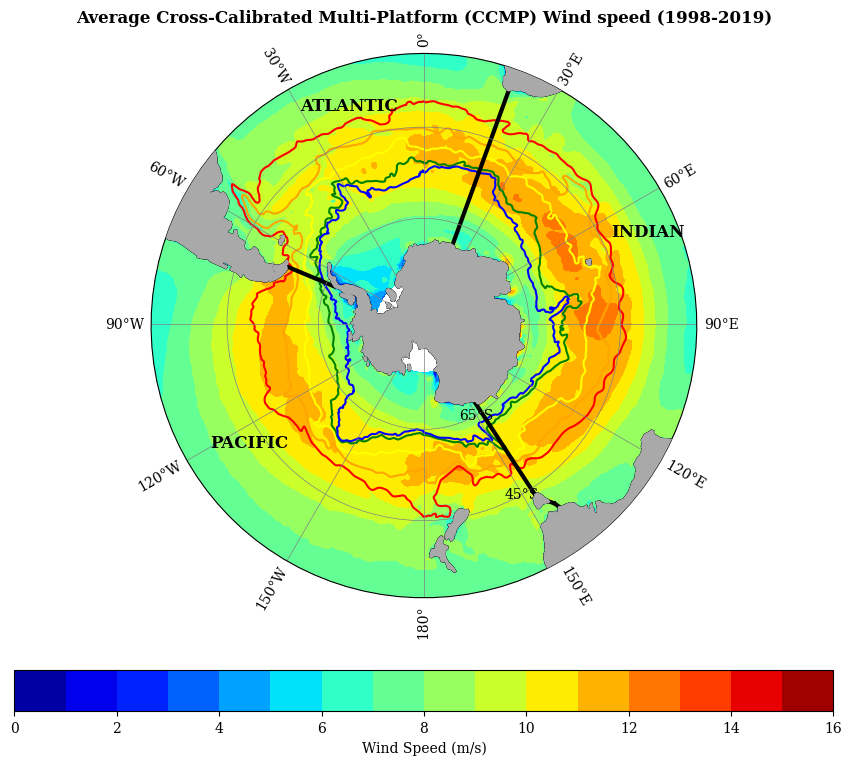

In [12]:
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -85, -30], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax.add_feature(cfeature.COASTLINE, linewidth=1.25)
ax.gridlines(ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='grey',
             xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-85, -30, 20))

io = pd.read_csv('/home/ubuntu/coordinates.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
ao = pd.read_csv('/home/ubuntu/coordinates_AO.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
po = pd.read_csv('/home/ubuntu/coordinates_PO.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
stf = pd.read_csv('/home/ubuntu/DATA/front/NB.txt', header=None, sep='\s+', na_values='%',
                  names=['lon', 'lat'])
saf = pd.read_csv('/home/ubuntu/DATA/front/saf.txt', header=None, sep='\s+', na_values='%',
                  names=['lon', 'lat'])
pf = pd.read_csv('/home/ubuntu/DATA/front/pf.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
saccf = pd.read_csv('/home/ubuntu/DATA/front/saccf.txt', header=None, sep='\s+', na_values='%',
                    names=['lon', 'lat'])
sbdy = pd.read_csv('/home/ubuntu/DATA/front/SB.txt', header=None, sep='\s+', na_values='%',
                   names=['lon', 'lat'])

plt.plot(stf['lon'], stf['lat'], color='Red', transform=ccrs.PlateCarree(), label='Northern Boundary')
plt.plot(saf['lon'], saf['lat'], color='Orange', transform=ccrs.PlateCarree(), label='Subantarctic Front')
plt.plot(pf['lon'], pf['lat'], color='Yellow', transform=ccrs.PlateCarree(), label='Polar Front')
plt.plot(saccf['lon'], saccf['lat'], color='Green', transform=ccrs.PlateCarree(), label='Southern ACC Front')
plt.plot(sbdy['lon'], sbdy['lat'], color='Blue', transform=ccrs.PlateCarree(), label='Southern Boundary')
plt.plot(io['lon'], io['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=3)
plt.plot(ao['lon'], ao['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=3)
plt.plot(po['lon'], po['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=3, zorder=2)

ax.add_feature(cfeature.COASTLINE, linewidth=1.25)

theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax.set_boundary(circle, transform=ax.transAxes)

clevs = np.arange(0, 17, 1)

im= ax.contourf(lon, lat, ds_mean.w.values, clevs, transform=ccrs.PlateCarree(),cmap=plt.cm.jet )

# Create the color bar
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.1, orientation='horizontal')
cbar.ax.set_xlabel('Wind Speed (m/s)')

ax.text(-30, -35, 'ATLANTIC', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')
ax.text(65, -43, 'INDIAN', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')
ax.text(-120, -35, 'PACIFIC', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')
ax.set_title("Average Cross-Calibrated Multi-Platform (CCMP) Wind speed (1998-2019)", fontweight='bold')

plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"

# Show the plot
plt.tight_layout()
#plt.savefig('Average Wind Speed.jpg', dpi=600)

## Map the wind field

This block places wind values on the Southern Ocean grid. Colour represents magnitude when a scalar field is plotted; arrows or streamlines represent direction when vector components are used.

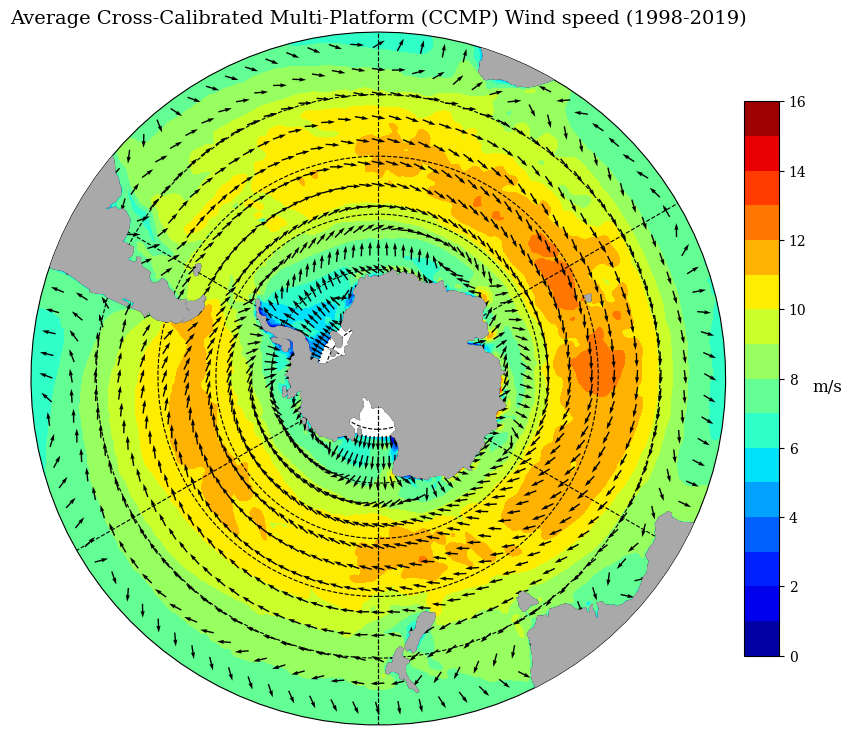

In [16]:
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())  # Set the map extent to focus on the South Polar region
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax.gridlines(linestyle='--', color='black')
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

#Plot windspeed:
#Set contour levels, then draw the plot and a colorbar
clevs = np.arange(0, 17, 1)
plt.contourf(lon, lat, ds_mean.w.values, clevs, transform=ccrs.PlateCarree(), cmap=plt.cm.jet)
plt.title('Average Cross-Calibrated Multi-Platform (CCMP) Wind speed (1998-2019)', size=14)
cb = plt.colorbar(ax=ax, orientation="vertical", pad=0.02, aspect=16, shrink=0.8)
cb.set_label('m/s', size=12, rotation=0, labelpad=15)
cb.ax.tick_params(labelsize=10)

magnitude = np.sqrt(xwind ** 2.0 + ywind ** 2.0)

# Normalize the wind vector components
u_norm = xwind / magnitude
v_norm = ywind / magnitude

# Plot the quiver plot with normalized vectors and other parameters
ax.quiver(lon[::15], lat[::15], u_norm[::15, ::15], v_norm[::15, ::15],
          transform=ccrs.PlateCarree(), color='k', pivot='middle', scale=50, width=0.002)
plt.show()

In [17]:
ds_average=ds.w.mean('lats').mean('lons')
ds_average

<xarray.DataArray 'w' (time: 264)>
array([7.5062594, 8.001628 , 8.471735 , 9.04012  , 9.181844 , 9.466786 ,
       9.537626 , 9.612929 , 9.368921 , 8.70099  , 8.331295 , 7.7334933,
       7.595626 , 8.130677 , 8.4107895, 8.904461 , 9.311517 , 9.26387  ,
       9.601472 , 9.489936 , 9.303582 , 8.940453 , 8.146068 , 7.748052 ,
       7.591357 , 7.9956355, 8.488738 , 8.964925 , 9.277934 , 9.182442 ,
       9.371748 , 9.397199 , 9.097758 , 8.629302 , 7.9724765, 7.4040895,
       7.2526546, 7.7609477, 8.404265 , 9.013408 , 9.097779 , 9.35032  ,
       9.411482 , 9.41782  , 9.314893 , 8.887542 , 8.217617 , 7.6689215,
       7.4346776, 8.16974  , 8.32823  , 8.880556 , 9.130768 , 9.173782 ,
       9.403497 , 9.243408 , 8.902032 , 8.4875   , 7.784207 , 7.553783 ,
       7.505044 , 7.8991475, 8.3433485, 8.831117 , 9.410513 , 9.2606535,
       9.593084 , 9.587953 , 9.25522  , 8.71854  , 8.020873 , 7.6194816,
       7.4650173, 7.9565315, 8.524907 , 8.826513 , 9.326567 , 9.372117 ,
       9.343313 , 9.509504 , 9.374039 , 8.861472 , 8.171635 , 7.59574  ,
       7.577219 , 8.01467  , 8.427672 , 9.166113 , 9.033983 , 9.162153 ,
       9.342167 , 9.657899 , 9.067776 , 8.7666025, 8.008365 , 7.513571 ,
       7.580364 , 7.9244494, 8.661878 , 8.981528 , 9.304803 , 9.521413 ,
       9.635506 , 9.254556 , 9.280116 , 8.797665 , 8.195753 , 7.50984  ,
       7.6981196, 7.8276334, 8.546015 , 8.909977 , 9.266037 , 9.307466 ,
       9.307114 , 9.502638 , 9.162996 , 8.886815 , 8.11322  , 7.764705 ,
...
       9.614421 , 9.521496 , 9.328285 , 9.019047 , 8.189765 , 7.7760053,
       7.607436 , 8.215673 , 8.530065 , 8.956019 , 9.224731 , 9.413437 ,
       9.309941 , 9.306704 , 9.148148 , 8.821997 , 8.260873 , 7.751203 ,
       7.7650647, 7.984176 , 8.649696 , 9.061048 , 9.153798 , 9.431233 ,
       9.433757 , 9.515882 , 9.366526 , 8.771318 , 8.078614 , 7.418393 ,
       7.5454617, 8.073264 , 8.536089 , 8.883162 , 9.1399145, 9.445453 ,
       9.441987 , 9.277848 , 9.213265 , 8.674072 , 8.28287  , 7.51044  ,
       7.5278077, 8.048184 , 8.486197 , 8.788324 , 9.213976 , 9.252729 ,
       9.352288 , 9.538444 , 9.241964 , 8.940299 , 8.046704 , 7.77229  ,
       7.7362576, 8.07784  , 8.502079 , 9.069997 , 9.239148 , 9.524741 ,
       9.558378 , 9.547867 , 9.362799 , 9.021485 , 8.540678 , 7.66786  ,
       7.773059 , 8.242362 , 8.695779 , 9.014208 , 9.1698065, 9.32537  ,
       9.506871 , 9.477615 , 9.46968  , 8.790607 , 8.026737 , 7.4820867,
       7.50576  , 7.9310737, 8.458398 , 9.043787 , 9.468384 , 9.42308  ,
       9.6105995, 9.384412 , 9.437512 , 8.78801  , 8.121186 , 7.656181 ,
       7.583515 , 8.0949135, 8.60154  , 8.850431 , 9.276969 , 9.409915 ,
       9.571077 , 9.447979 , 9.417741 , 8.790181 , 8.335883 , 7.7515244,
       7.7212095, 8.026724 , 8.576448 , 9.091704 , 9.212009 , 9.4709215,
       9.178216 , 9.458124 , 9.239356 , 8.71077  , 7.9028935, 7.3467073],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1998-01-01 1998-02-01 ... 2019-12-01

Text(0, 0.5, 'm/s')

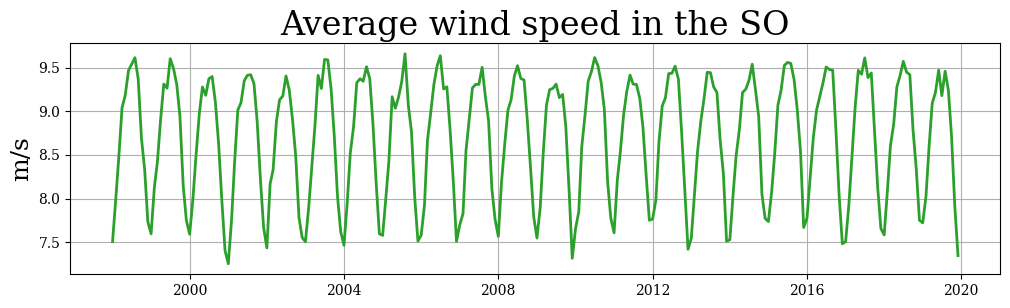

In [20]:
f = plt.figure(figsize=(12,3))
plt.plot(ds_average.time,ds_average.values,c='tab:green',linewidth=2)
plt.title("Average wind speed in the SO",fontsize=24)
plt.grid()
plt.ylabel("m/s",fontsize=18)

In [4]:
anomaly= ds.w_anom
anomaly = anomaly.assign_coords(time = ("time", np.arange(0, anomaly.shape[0])))
anomaly = anomaly.reset_coords(drop = True)

# Apply a linear regression where x = time and y = sst anomaly for each pixel
regression = anomaly.polyfit("time", 1, skipna = True, full = True)

# Calculate the annual rate of change in sst for each pixel
total_climatology = ds.w.mean("time")
pixel_rates = (regression.polyfit_coefficients.sel(degree = 1) * 12) / (regression.polyfit_coefficients.sel(degree = 0) + total_climatology)

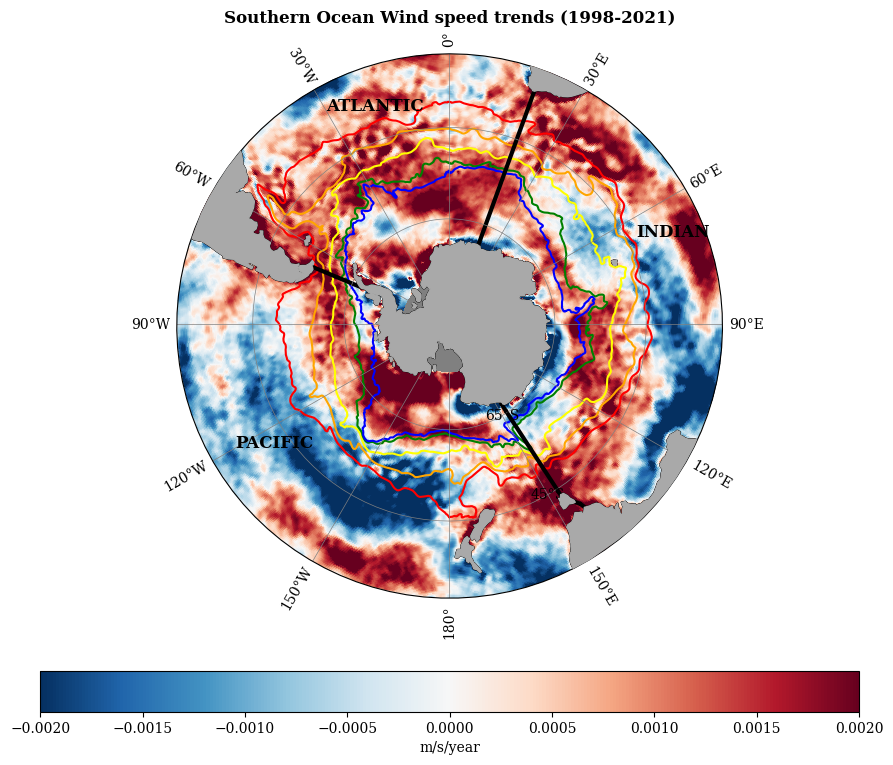

In [22]:
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -85, -30], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax.add_feature(cfeature.COASTLINE, linewidth=1.25)
ax.gridlines(ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='grey',
             xlocs=np.arange(-180, 180, 30), ylocs=np.arange(-85, -30, 20))

io = pd.read_csv('/home/ubuntu/coordinates.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
ao = pd.read_csv('/home/ubuntu/coordinates_AO.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
po = pd.read_csv('/home/ubuntu/coordinates_PO.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
stf = pd.read_csv('/home/ubuntu/DATA/front/NB.txt', header=None, sep='\s+', na_values='%',
                  names=['lon', 'lat'])
saf = pd.read_csv('/home/ubuntu/DATA/front/saf.txt', header=None, sep='\s+', na_values='%',
                  names=['lon', 'lat'])
pf = pd.read_csv('/home/ubuntu/DATA/front/pf.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
saccf = pd.read_csv('/home/ubuntu/DATA/front/saccf.txt', header=None, sep='\s+', na_values='%',
                    names=['lon', 'lat'])
sbdy = pd.read_csv('/home/ubuntu/DATA/front/SB.txt', header=None, sep='\s+', na_values='%',
                   names=['lon', 'lat'])

plt.plot(stf['lon'], stf['lat'], color='Red', transform=ccrs.PlateCarree(), label='Northern Boundary')
plt.plot(saf['lon'], saf['lat'], color='Orange', transform=ccrs.PlateCarree(), label='Subantarctic Front')
plt.plot(pf['lon'], pf['lat'], color='Yellow', transform=ccrs.PlateCarree(), label='Polar Front')
plt.plot(saccf['lon'], saccf['lat'], color='Green', transform=ccrs.PlateCarree(), label='Southern ACC Front')
plt.plot(sbdy['lon'], sbdy['lat'], color='Blue', transform=ccrs.PlateCarree(), label='Southern Boundary')
plt.plot(io['lon'], io['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=3)
plt.plot(ao['lon'], ao['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=3)
plt.plot(po['lon'], po['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=3, zorder=2)

ax.add_feature(cfeature.COASTLINE, linewidth=1.25)

theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax.set_boundary(circle, transform=ax.transAxes)

colormap = plt.cm.get_cmap('RdBu_r').copy()
colormap.set_bad(color='gray')

im = ax.pcolormesh(lon, lat, pixel_rates.values, cmap=colormap,
                   vmin=-0.002, vmax=0.002, transform=ccrs.PlateCarree())

# Create the color bar
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.1, orientation='horizontal')
cbar.ax.set_xlabel('m/s/year')

ax.text(-30, -35, 'ATLANTIC', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')
ax.text(65, -43, 'INDIAN', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')
ax.text(-120, -35, 'PACIFIC', transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')
ax.set_title("Southern Ocean Wind speed trends (1998-2021)", fontweight='bold')

plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"
plt.tight_layout()